In [1]:
!pip install lightgbm optuna shap imbalanced-learn xgboost scikit-learn pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 3.3 MB/s eta 0:00:01
   --------------------- ------------------ 0.8/1.5 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [lightgbm]
   ------------- -------------------------- 1/3 [lightgbm]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optuna]
   -------------------------- ------------- 2/3 [optu

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# LightGBM
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Optuna
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

print("✅ All libraries imported successfully!")
print(f"LightGBM version: {lgb.__version__}")

✅ All libraries imported successfully!
LightGBM version: 4.6.0


In [3]:
# Load datasets
df        = pd.read_csv("train_transactions.csv")
train_df  = pd.read_csv("train_transactions.csv")
test_df   = pd.read_csv("test_transactions.csv")

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
display(df.describe())

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
fraud_counts = df['is_fraud'].value_counts()
print(fraud_counts)

fraud_ratio = fraud_counts[1] / fraud_counts[0]
print(f"\nFraud to Legitimate Ratio : {fraud_ratio:.4f}")
print(f"Fraud Percentage          : {fraud_ratio * 100:.2f}%")
print(f"Imbalance Ratio           : 1:{int(1/fraud_ratio)}")

# Computed class weight for reference
neg = fraud_counts[0]
pos = fraud_counts[1]
scale_pos_weight = neg / pos
print(f"\nRecommended scale_pos_weight for XGBoost : {scale_pos_weight:.2f}")
print(f"(This is what class_weight='balanced' does internally)")

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           15000 non-null  object 
 1   cardholder_id            15000 non-null  object 
 2   merchant_id              15000 non-null  object 
 3   merchant_category        15000 non-null  object 
 4   transaction_timestamp    15000 non-null  object 
 5   transaction_hour         15000 non-null  int64  
 6   transaction_day_of_week  15000 non-null  int64  
 7   transaction_amount_inr   15000 non-null  float64
 8   country_code             15000 non-null  object 
 9   is_international         15000 non-null  int64  
 10  pos_entry_mode           15000 non-null  object 
 11  velocity_last_1h         15000 non-null  int64  
 12  velocity_last_24h        15000 non-null  int64  
 13  avg_txn_amount_30d       15000 non-null  float64
 14  std_txn_a

,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,credit_limit_inr,is_fraud
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,11.573733,3.000867,206.033039,0.142400,1.631933,4.223067,128.087811,302.232643,223.324500,919.174533,196436.666667,0.017800
std,6.972169,1.997448,412.915154,0.349472,1.554549,3.222173,103.388213,145.983226,616.543479,510.303410,146073.526533,0.132228
min,0.000000,0.000000,2.810000,0.000000,0.000000,0.000000,6.290000,0.000000,0.000000,30.000000,50000.000000,0.000000
25%,6.000000,1.000000,67.300000,0.000000,1.000000,2.000000,62.337500,197.990000,77.800000,479.750000,75000.000000,0.000000
50%,12.000000,3.000000,122.970000,0.000000,2.000000,4.000000,100.325000,299.960000,153.700000,921.000000,150000.000000,0.000000
75%,18.000000,5.000000,226.732500,0.000000,3.000000,6.000000,160.512500,401.035000,228.900000,1358.000000,300000.000000,0.000000
max,23.000000,6.000000,17313.630000,1.000000,15.000000,30.000000,2660.130000,915.050000,7972.200000,1800.000000,500000.000000,1.000000



CLASS DISTRIBUTION
is_fraud
0    14733
1      267
Name: count, dtype: int64

Fraud to Legitimate Ratio : 0.0181
Fraud Percentage          : 1.81%
Imbalance Ratio           : 1:55

Recommended scale_pos_weight for XGBoost : 55.18
(This is what class_weight='balanced' does internally)


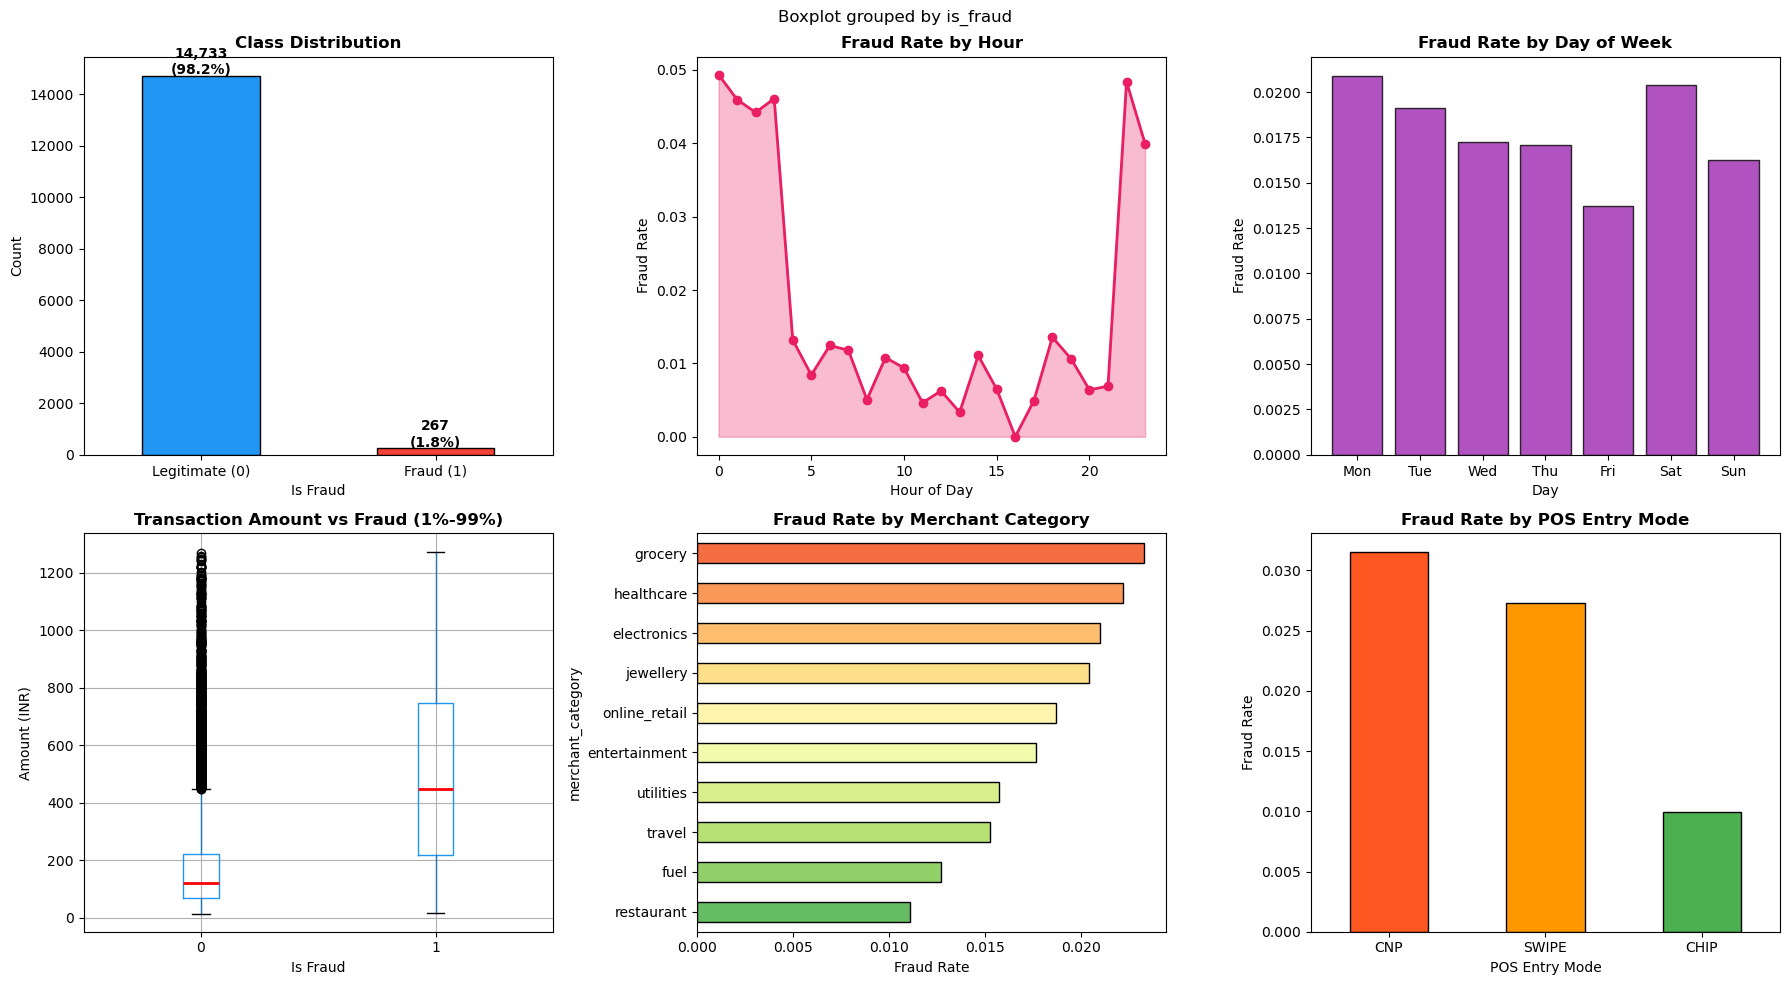

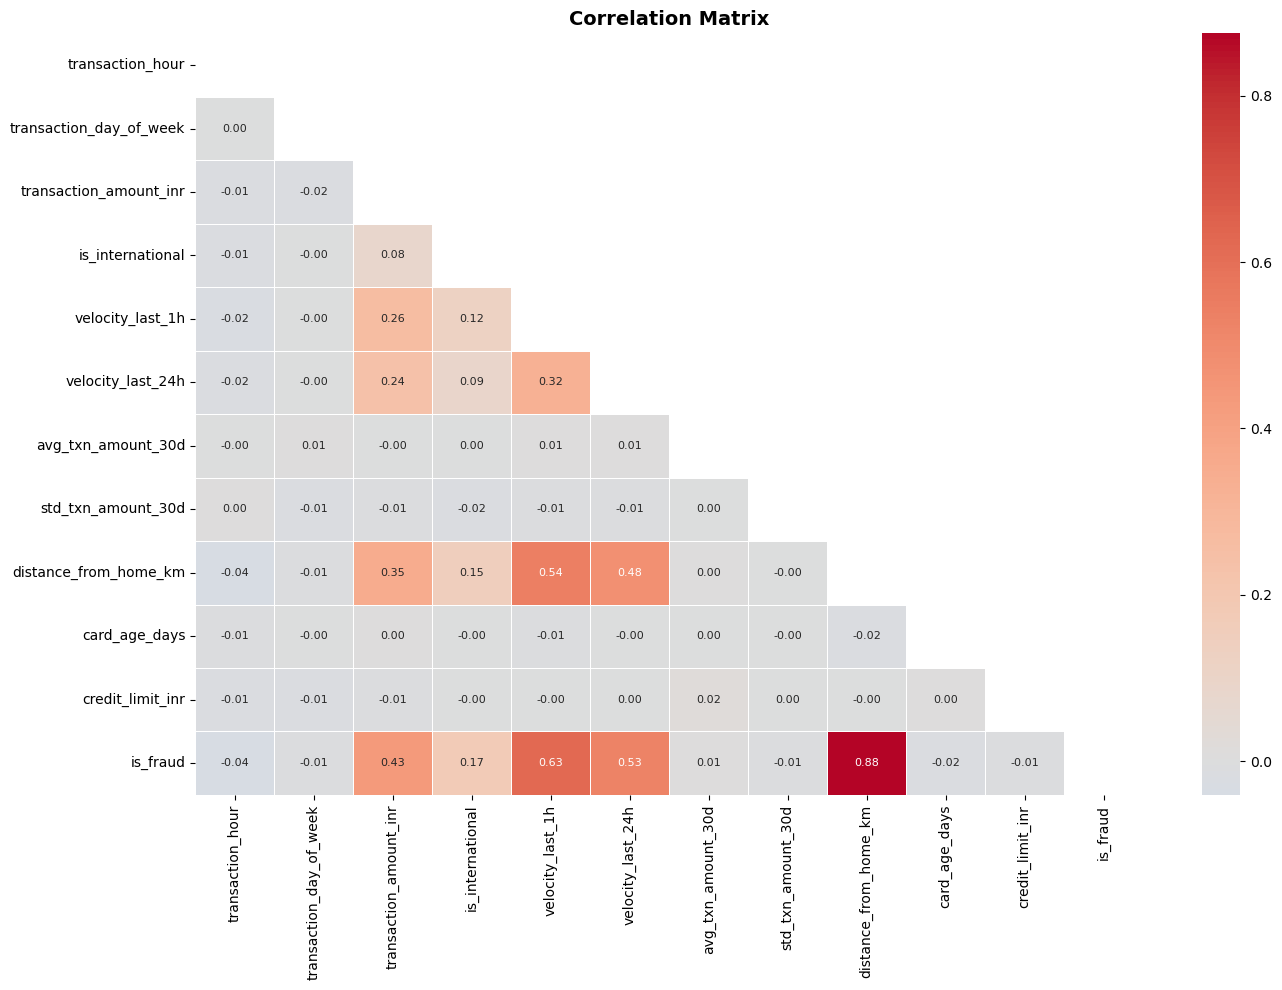


Missing Values:
transaction_id             0
cardholder_id              0
merchant_id                0
merchant_category          0
transaction_timestamp      0
transaction_hour           0
transaction_day_of_week    0
transaction_amount_inr     0
country_code               0
is_international           0
pos_entry_mode             0
velocity_last_1h           0
velocity_last_24h          0
avg_txn_amount_30d         0
std_txn_amount_30d         0
distance_from_home_km      0
card_age_days              0
credit_limit_inr           0
is_fraud                   0
dtype: int64

Duplicate Rows: 0


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis - Fraud Detection", fontsize=16, fontweight='bold')

# 1. Class Distribution
ax1 = axes[0, 0]
colors = ['#2196F3', '#F44336']
fraud_counts.plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title("Class Distribution", fontweight='bold')
ax1.set_xlabel("Is Fraud")
ax1.set_ylabel("Count")
ax1.set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
for i, v in enumerate(fraud_counts):
    ax1.text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# 2. Fraud Rate by Hour
ax2 = axes[0, 1]
hourly_fraud = df.groupby('transaction_hour')['is_fraud'].mean()
ax2.plot(hourly_fraud.index, hourly_fraud.values, marker='o', color='#E91E63', linewidth=2)
ax2.fill_between(hourly_fraud.index, hourly_fraud.values, alpha=0.3, color='#E91E63')
ax2.set_title("Fraud Rate by Hour", fontweight='bold')
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Fraud Rate")

# 3. Fraud Rate by Day of Week
ax3 = axes[0, 2]
day_fraud = df.groupby('transaction_day_of_week')['is_fraud'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax3.bar(range(len(day_fraud)), day_fraud.values, color='#9C27B0', edgecolor='black', alpha=0.8)
ax3.set_title("Fraud Rate by Day of Week", fontweight='bold')
ax3.set_xlabel("Day")
ax3.set_ylabel("Fraud Rate")
ax3.set_xticks(range(len(day_fraud)))
ax3.set_xticklabels(day_names[:len(day_fraud)])

# 4. Transaction Amount vs Fraud
ax4 = axes[1, 0]
lower = df['transaction_amount_inr'].quantile(0.01)
upper = df['transaction_amount_inr'].quantile(0.99)
df_clip = df[(df['transaction_amount_inr'] >= lower) & (df['transaction_amount_inr'] <= upper)]
df_clip.boxplot(column='transaction_amount_inr', by='is_fraud', ax=ax4,
                boxprops=dict(color='#2196F3'),
                medianprops=dict(color='red', linewidth=2))
ax4.set_title("Transaction Amount vs Fraud (1%-99%)", fontweight='bold')
ax4.set_xlabel("Is Fraud")
ax4.set_ylabel("Amount (INR)")

# 5. Fraud Rate by Merchant Category
ax5 = axes[1, 1]
merchant_fraud = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=True)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(merchant_fraud)))
merchant_fraud.plot(kind='barh', ax=ax5, color=colors_bar, edgecolor='black')
ax5.set_title("Fraud Rate by Merchant Category", fontweight='bold')
ax5.set_xlabel("Fraud Rate")

# 6. Fraud Rate by POS Mode
ax6 = axes[1, 2]
pos_fraud = df.groupby('pos_entry_mode')['is_fraud'].mean().sort_values(ascending=False)
pos_fraud.plot(kind='bar', ax=ax6, color=['#FF5722', '#FF9800', '#4CAF50'], edgecolor='black')
ax6.set_title("Fraud Rate by POS Entry Mode", fontweight='bold')
ax6.set_xlabel("POS Entry Mode")
ax6.set_ylabel("Fraud Rate")
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={"size": 8})
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

In [5]:
# Drop identifier and high-cardinality columns
drop_cols = ['transaction_id', 'cardholder_id', 'merchant_id', 'distance_from_home_km']

train_df = train_df.drop(columns=drop_cols, errors='ignore')
test_df  = test_df.drop(columns=drop_cols, errors='ignore')

# Remove duplicates
train_df = train_df.drop_duplicates()

print(f"Train shape after cleaning : {train_df.shape}")
print(f"Test shape after cleaning  : {test_df.shape}")
print("\nNull values in train:")
print(train_df.isnull().sum())

Train shape after cleaning : (15000, 15)
Test shape after cleaning  : (5000, 14)

Null values in train:
merchant_category          0
transaction_timestamp      0
transaction_hour           0
transaction_day_of_week    0
transaction_amount_inr     0
country_code               0
is_international           0
pos_entry_mode             0
velocity_last_1h           0
velocity_last_24h          0
avg_txn_amount_30d         0
std_txn_amount_30d         0
card_age_days              0
credit_limit_inr           0
is_fraud                   0
dtype: int64


In [6]:
def process_time(df):
    """Extract time-based features from transaction_timestamp."""
    df = df.copy()
    df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
    df['txn_hour']    = df['transaction_timestamp'].dt.hour
    df['txn_day']     = df['transaction_timestamp'].dt.day
    df['txn_month']   = df['transaction_timestamp'].dt.month
    df['txn_weekday'] = df['transaction_timestamp'].dt.weekday
    # Is weekend?
    df['is_weekend']  = (df['txn_weekday'] >= 5).astype(int)
    # Is night transaction? (10pm - 6am)
    df['is_night_txn'] = ((df['txn_hour'] >= 22) | (df['txn_hour'] <= 6)).astype(int)
    df = df.drop(columns=['transaction_timestamp'])
    return df

train_df = process_time(train_df)
test_df  = process_time(test_df)

print("✅ Time features created!")
print(f"New columns: txn_hour, txn_day, txn_month, txn_weekday, is_weekend, is_night_txn")

✅ Time features created!
New columns: txn_hour, txn_day, txn_month, txn_weekday, is_weekend, is_night_txn


In [7]:
def add_features(df):
    """Add domain-specific fraud detection features."""
    df = df.copy()

    # Amount vs average ratio (higher = suspicious)
    df['amount_vs_avg_ratio'] = (
        df['transaction_amount_inr'] / (df['avg_txn_amount_30d'] + 1)
    )

    # Amount vs credit limit ratio
    df['amount_to_limit_ratio'] = (
        df['transaction_amount_inr'] / (df['credit_limit_inr'] + 1)
    )

    # International + high amount flag (very suspicious combo)
    df['international_high_amount'] = (
        (df['is_international'] == 1) & (df['transaction_amount_inr'] > 1000)
    ).astype(int)

    # Amount deviation from 30-day std
    df['amount_zscore'] = (
        (df['transaction_amount_inr'] - df['avg_txn_amount_30d'])
        / (df['std_txn_amount_30d'] + 1)
    )

    # High velocity flag
    # Note: velocity cols dropped if leak, but kept here for feature engineering
    # Amount much larger than usual
    df['is_large_txn'] = (df['amount_vs_avg_ratio'] > 3).astype(int)

    return df

train_df = add_features(train_df)
test_df  = add_features(test_df)

print("✅ Domain features added!")
new_features = ['amount_vs_avg_ratio', 'amount_to_limit_ratio',
                'international_high_amount', 'amount_zscore', 'is_large_txn']
print(f"New features: {new_features}")

✅ Domain features added!
New features: ['amount_vs_avg_ratio', 'amount_to_limit_ratio', 'international_high_amount', 'amount_zscore', 'is_large_txn']


In [8]:
TARGET = 'is_fraud'

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

# Stratified split to preserve fraud ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size       : {X_train.shape[0]:,}")
print(f"Validation size  : {X_val.shape[0]:,}")
print(f"\nTrain fraud rate : {y_train.mean():.4f} ({y_train.sum()} fraud cases)")
print(f"Val fraud rate   : {y_val.mean():.4f} ({y_val.sum()} fraud cases)")

Train size       : 12,000
Validation size  : 3,000

Train fraud rate : 0.0178 (214 fraud cases)
Val fraud rate   : 0.0177 (53 fraud cases)


In [9]:
cat_cols = ['merchant_category', 'country_code', 'pos_entry_mode']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))

    # Handle unseen categories in validation/test
    known_classes = set(le.classes_)
    X_val[col] = X_val[col].astype(str).apply(
        lambda x: x if x in known_classes else le.classes_[0]
    )
    X_val[col] = le.transform(X_val[col])

    encoders[col] = le

print(f"✅ Encoded columns: {cat_cols}")
print(f"Sample encoding - merchant_category: {dict(zip(le.classes_[:5], range(5)))}")

✅ Encoded columns: ['merchant_category', 'country_code', 'pos_entry_mode']
Sample encoding - merchant_category: {'CHIP': 0, 'CNP': 1, 'SWIPE': 2}


In [10]:
# velocity columns are potential leakage (computed from future)
leak_cols = ['velocity_last_1h', 'velocity_last_24h']

X_train = X_train.drop(columns=leak_cols, errors='ignore')
X_val   = X_val.drop(columns=leak_cols, errors='ignore')

print(f"✅ Dropped leakage columns: {leak_cols}")
print(f"Final feature count: {X_train.shape[1]}")
print(f"\nFeatures used:\n{list(X_train.columns)}")

✅ Dropped leakage columns: ['velocity_last_1h', 'velocity_last_24h']
Final feature count: 22

Features used:
['merchant_category', 'transaction_hour', 'transaction_day_of_week', 'transaction_amount_inr', 'country_code', 'is_international', 'pos_entry_mode', 'avg_txn_amount_30d', 'std_txn_amount_30d', 'card_age_days', 'credit_limit_inr', 'txn_hour', 'txn_day', 'txn_month', 'txn_weekday', 'is_weekend', 'is_night_txn', 'amount_vs_avg_ratio', 'amount_to_limit_ratio', 'international_high_amount', 'amount_zscore', 'is_large_txn']


In [11]:
# Note: Tree-based models (RF, XGB, LGBM) don't require scaling
# But keeping it doesn't hurt and makes the pipeline consistent
# For future use with SVM, LogisticRegression etc.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Keep DataFrames for SHAP (needs feature names)
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_val_df   = pd.DataFrame(X_val_scaled,   columns=X_val.columns)

print("✅ Scaling applied!")
print("Note: Tree models work directly on unscaled data too.")
print(f"Scaler fitted on {X_train.shape[0]:,} training samples.")

# Class weight calculation (to replace SMOTE/ADASYN)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_val = neg_count / pos_count

print(f"\n📊 Class Weight Analysis:")
print(f"  Legitimate (0) : {neg_count:,}")
print(f"  Fraud (1)      : {pos_count:,}")
print(f"  scale_pos_weight : {scale_pos_weight_val:.2f}")
print(f"\n✅ Using class_weight='balanced' instead of SMOTE")
print("   → More robust, no data augmentation artifacts")

✅ Scaling applied!
Note: Tree models work directly on unscaled data too.
Scaler fitted on 12,000 training samples.

📊 Class Weight Analysis:
  Legitimate (0) : 11,786
  Fraud (1)      : 214
  scale_pos_weight : 55.07

✅ Using class_weight='balanced' instead of SMOTE
   → More robust, no data augmentation artifacts


In [12]:
def evaluate_model(model_name, y_true, y_prob, y_pred, threshold=0.5):
    """
    Comprehensive evaluation for imbalanced fraud detection.
    Returns a dictionary of all metrics.
    """
    print(f"\n{'='*60}")
    print(f"  MODEL: {model_name}")
    print(f"  Threshold: {threshold}")
    print(f"{'='*60}")

    # Core metrics
    acc      = accuracy_score(y_true, y_pred)
    prec     = precision_score(y_true, y_pred, zero_division=0)
    rec      = recall_score(y_true, y_pred, zero_division=0)
    f1       = f1_score(y_true, y_pred, zero_division=0)
    roc_auc  = roc_auc_score(y_true, y_prob)
    avg_prec = average_precision_score(y_true, y_prob)  # PR-AUC

    print(f"\n📊 Core Metrics:")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Precision (Fraud) : {prec:.4f}")
    print(f"  Recall (Fraud)    : {rec:.4f}  ← Most important for fraud!")
    print(f"  F1 Score (Fraud)  : {f1:.4f}")
    print(f"  ROC-AUC           : {roc_auc:.4f}")
    print(f"  PR-AUC            : {avg_prec:.4f}  ← Better for imbalanced!")

    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Fraud']))

    print(f"\n🔢 Confusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
    print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
    print(f"\n  False Positive Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.4f} (legit flagged as fraud)")
    print(f"  False Negative Rate : {cm[1,0]/(cm[1,0]+cm[1,1]):.4f} (fraud missed!)")

    return {
        'model': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': avg_prec,
        'confusion_matrix': cm
    }


def plot_roc_pr_curves(results_list, y_true, prob_dict):
    """Plot ROC and PR curves for all models side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Model Comparison: ROC & PR Curves", fontsize=14, fontweight='bold')

    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

    for i, (name, y_prob) in enumerate(prob_dict.items()):
        color = colors[i % len(colors)]

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_val = roc_auc_score(y_true, y_prob)
        axes[0].plot(fpr, tpr, color=color, linewidth=2,
                     label=f'{name} (AUC={auc_val:.3f})')

        # PR Curve
        prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_prob)
        pr_auc = average_precision_score(y_true, y_prob)
        axes[1].plot(rec_vals, prec_vals, color=color, linewidth=2,
                     label=f'{name} (PR-AUC={pr_auc:.3f})')

    # ROC plot formatting
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(alpha=0.3)

    # PR plot formatting
    fraud_rate = y_true.mean()
    axes[1].axhline(y=fraud_rate, color='k', linestyle='--', linewidth=1,
                    label=f'Random ({fraud_rate:.3f})')
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].set_title('Precision-Recall Curve\n(Better metric for imbalanced data)',
                      fontsize=12, fontweight='bold')
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, model_name, ax=None):
    """Plot a nice confusion matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    labels = ['Legitimate', 'Fraud']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                ax=ax, cbar=True, linewidths=0.5)
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    ax.set_ylabel('Actual', fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')


print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


In [13]:
print("🌲 Training Random Forest with class_weight='balanced'...")
print("   (No SMOTE needed — class_weight handles imbalance internally)\n")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',      # ← Key: handles imbalance
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_df, y_train)

# Predict
y_prob_rf = rf_model.predict_proba(X_val_df)[:, 1]
threshold_rf = 0.35  # Lower threshold = more sensitive to fraud
y_pred_rf = (y_prob_rf > threshold_rf).astype(int)

# Evaluate
rf_results = evaluate_model("Random Forest", y_val, y_prob_rf, y_pred_rf, threshold=threshold_rf)

🌲 Training Random Forest with class_weight='balanced'...
   (No SMOTE needed — class_weight handles imbalance internally)


  MODEL: Random Forest
  Threshold: 0.35

📊 Core Metrics:
  Accuracy          : 0.9713
  Precision (Fraud) : 0.3486
  Recall (Fraud)    : 0.7170  ← Most important for fraud!
  F1 Score (Fraud)  : 0.4691
  ROC-AUC           : 0.9586
  PR-AUC            : 0.5646  ← Better for imbalanced!

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.98      0.99      2947
       Fraud       0.35      0.72      0.47        53

    accuracy                           0.97      3000
   macro avg       0.67      0.85      0.73      3000
weighted avg       0.98      0.97      0.98      3000


🔢 Confusion Matrix:
  TN=2876  FP=  71
  FN=  15  TP=  38

  False Positive Rate : 0.0241 (legit flagged as fraud)
  False Negative Rate : 0.2830 (fraud missed!)


In [14]:
print("🔧 Optuna Hyperparameter Tuning for XGBoost...")
print("   Using scale_pos_weight instead of SMOTE\n")

def xgb_objective(trial):
    """Optuna objective for XGBoost — optimizes ROC-AUC."""
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight'  : scale_pos_weight_val,  # ← Imbalance handling
        'use_label_encoder' : False,
        'eval_metric'       : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1,
    }

    # Stratified K-Fold cross-validation
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    model = XGBClassifier(**params)

    scores = cross_val_score(
        model, X_train_df, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()


# Run Optuna study
xgb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='XGBoost_Fraud'
)

xgb_study.optimize(
    xgb_objective,
    n_trials=30,         # Increase to 50-100 for better results
    show_progress_bar=True
)

print(f"\n✅ Best XGBoost ROC-AUC: {xgb_study.best_value:.4f}")
print(f"Best Parameters: {xgb_study.best_params}")

🔧 Optuna Hyperparameter Tuning for XGBoost...
   Using scale_pos_weight instead of SMOTE



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best XGBoost ROC-AUC: 0.9418
Best Parameters: {'n_estimators': 403, 'max_depth': 6, 'learning_rate': 0.08087625293965638, 'subsample': 0.85056957489987, 'colsample_bytree': 0.7465516661768355, 'min_child_weight': 9, 'gamma': 1.584176056288116, 'reg_alpha': 1.077399364212968e-07, 'reg_lambda': 3.776482713923282e-06}


In [15]:
# Train final XGBoost with best params
best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({
    'scale_pos_weight'  : scale_pos_weight_val,
    'use_label_encoder' : False,
    'eval_metric'       : 'auc',
    'random_state'      : 42,
    'n_jobs'            : -1,
})

xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    verbose=False
)

# Predict
y_prob_xgb = xgb_model.predict_proba(X_val_df)[:, 1]
threshold_xgb = 0.35
y_pred_xgb = (y_prob_xgb > threshold_xgb).astype(int)

# Evaluate
xgb_results = evaluate_model("XGBoost (Optuna)", y_val, y_prob_xgb, y_pred_xgb, threshold=threshold_xgb)


  MODEL: XGBoost (Optuna)
  Threshold: 0.35

📊 Core Metrics:
  Accuracy          : 0.9870
  Precision (Fraud) : 0.6029
  Recall (Fraud)    : 0.7736  ← Most important for fraud!
  F1 Score (Fraud)  : 0.6777
  ROC-AUC           : 0.9758
  PR-AUC            : 0.7729  ← Better for imbalanced!

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99      2947
       Fraud       0.60      0.77      0.68        53

    accuracy                           0.99      3000
   macro avg       0.80      0.88      0.84      3000
weighted avg       0.99      0.99      0.99      3000


🔢 Confusion Matrix:
  TN=2920  FP=  27
  FN=  12  TP=  41

  False Positive Rate : 0.0092 (legit flagged as fraud)
  False Negative Rate : 0.2264 (fraud missed!)


In [16]:
print("⚡ Optuna Hyperparameter Tuning for LightGBM...")
print("   Using is_unbalance=True for imbalance handling\n")

def lgbm_objective(trial):
    """Optuna objective for LightGBM."""
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'is_unbalance'      : True,    # ← LightGBM native imbalance handling
        'objective'         : 'binary',
        'metric'            : 'auc',
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    model = LGBMClassifier(**params)

    scores = cross_val_score(
        model, X_train_df, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )
    return scores.mean()


lgbm_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42),
    study_name='LightGBM_Fraud'
)

lgbm_study.optimize(
    lgbm_objective,
    n_trials=30,
    show_progress_bar=True
)

print(f"\n✅ Best LightGBM ROC-AUC: {lgbm_study.best_value:.4f}")
print(f"Best Parameters: {lgbm_study.best_params}")

⚡ Optuna Hyperparameter Tuning for LightGBM...
   Using is_unbalance=True for imbalance handling



  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best LightGBM ROC-AUC: 0.9381
Best Parameters: {'n_estimators': 472, 'max_depth': 11, 'learning_rate': 0.01626429295188138, 'num_leaves': 136, 'min_child_samples': 70, 'subsample': 0.7699849370722993, 'colsample_bytree': 0.9565865275705226, 'reg_alpha': 0.0017621515906654716, 'reg_lambda': 2.1160628387746637e-08}


In [17]:
# Train final LightGBM with best params
best_lgbm_params = lgbm_study.best_params.copy()
best_lgbm_params.update({
    'is_unbalance' : True,
    'objective'    : 'binary',
    'metric'       : 'auc',
    'random_state' : 42,
    'n_jobs'       : -1,
    'verbose'      : -1,
})

lgbm_model = LGBMClassifier(**best_lgbm_params)
lgbm_model.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

# Predict
y_prob_lgbm = lgbm_model.predict_proba(X_val_df)[:, 1]
threshold_lgbm = 0.35
y_pred_lgbm = (y_prob_lgbm > threshold_lgbm).astype(int)

# Evaluate
lgbm_results = evaluate_model("LightGBM (Optuna)", y_val, y_prob_lgbm, y_pred_lgbm, threshold=threshold_lgbm)


  MODEL: LightGBM (Optuna)
  Threshold: 0.35

📊 Core Metrics:
  Accuracy          : 0.9793
  Precision (Fraud) : 0.4554
  Recall (Fraud)    : 0.8679  ← Most important for fraud!
  F1 Score (Fraud)  : 0.5974
  ROC-AUC           : 0.9781
  PR-AUC            : 0.7320  ← Better for imbalanced!

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99      2947
       Fraud       0.46      0.87      0.60        53

    accuracy                           0.98      3000
   macro avg       0.73      0.92      0.79      3000
weighted avg       0.99      0.98      0.98      3000


🔢 Confusion Matrix:
  TN=2892  FP=  55
  FN=   7  TP=  46

  False Positive Rate : 0.0187 (legit flagged as fraud)
  False Negative Rate : 0.1321 (fraud missed!)


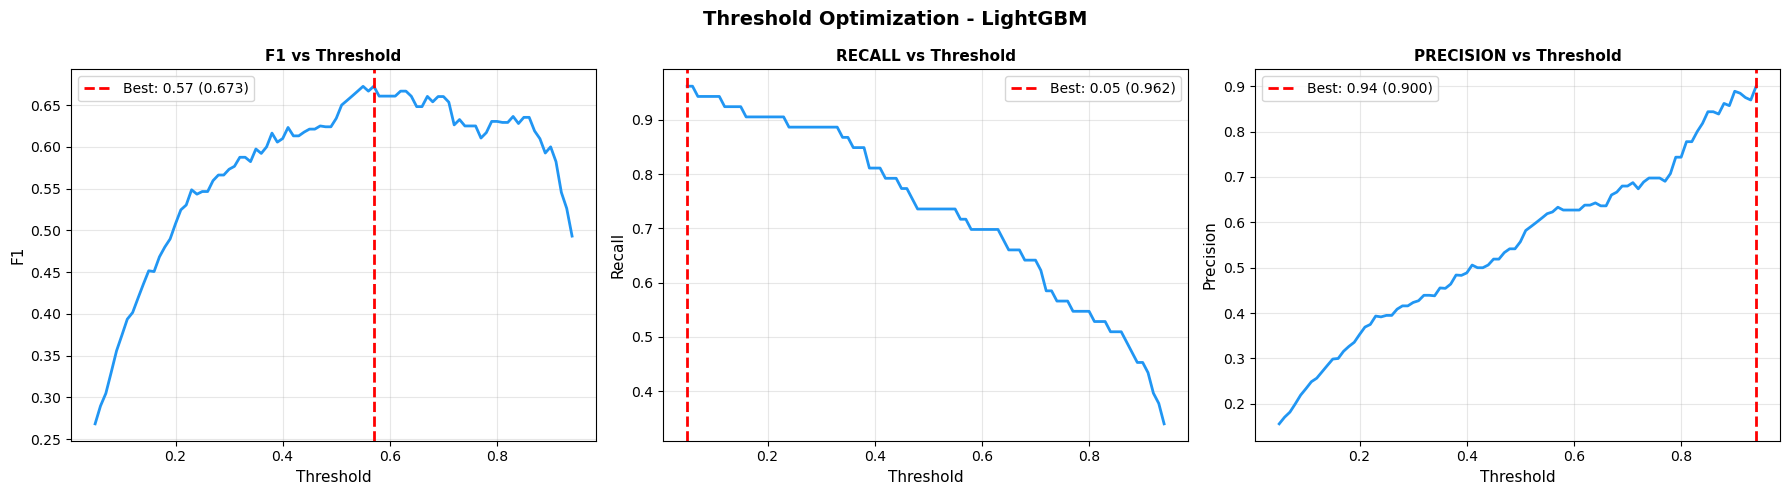

🎯 Optimal Thresholds (F1-optimized):
  Random Forest        → threshold=0.52, F1=0.5657
  XGBoost              → threshold=0.70, F1=0.7129
  LightGBM             → threshold=0.57, F1=0.6726


In [18]:
def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """
    Find threshold that maximizes F1 or Recall.
    For fraud detection, we often prefer higher recall (catch more fraud).
    """
    thresholds = np.arange(0.05, 0.95, 0.01)
    scores = []

    for thresh in thresholds:
        y_pred_t = (y_prob > thresh).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred_t, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred_t, zero_division=0)
        elif metric == 'precision':
            score = precision_score(y_true, y_pred_t, zero_division=0)
        scores.append(score)

    best_idx = np.argmax(scores)
    best_threshold = thresholds[best_idx]
    best_score = scores[best_idx]

    return best_threshold, best_score, thresholds, scores


# Plot threshold vs metrics for best model (LightGBM)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Threshold Optimization - LightGBM", fontsize=14, fontweight='bold')

for idx, (metric, ax) in enumerate(zip(['f1', 'recall', 'precision'], axes)):
    best_t, best_s, thresholds, scores = find_optimal_threshold(y_val, y_prob_lgbm, metric)
    ax.plot(thresholds, scores, linewidth=2, color='#2196F3')
    ax.axvline(best_t, color='red', linestyle='--', linewidth=2,
               label=f'Best: {best_t:.2f} ({best_s:.3f})')
    ax.set_xlabel('Threshold', fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f'{metric.upper()} vs Threshold', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal F1 threshold for each model
print("🎯 Optimal Thresholds (F1-optimized):")
for name, y_prob in [("Random Forest", y_prob_rf),
                      ("XGBoost",       y_prob_xgb),
                      ("LightGBM",      y_prob_lgbm)]:
    best_t, best_f1, _, _ = find_optimal_threshold(y_val, y_prob, 'f1')
    print(f"  {name:20s} → threshold={best_t:.2f}, F1={best_f1:.4f}")


  MODEL: Random Forest
  Threshold: 0.5

📊 Core Metrics:
  Accuracy          : 0.9857
  Precision (Fraud) : 0.6087
  Recall (Fraud)    : 0.5283  ← Most important for fraud!
  F1 Score (Fraud)  : 0.5657
  ROC-AUC           : 0.9586
  PR-AUC            : 0.5646  ← Better for imbalanced!

📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      2947
       Fraud       0.61      0.53      0.57        53

    accuracy                           0.99      3000
   macro avg       0.80      0.76      0.78      3000
weighted avg       0.98      0.99      0.99      3000


🔢 Confusion Matrix:
  TN=2929  FP=  18
  FN=  25  TP=  28

  False Positive Rate : 0.0061 (legit flagged as fraud)
  False Negative Rate : 0.4717 (fraud missed!)

  MODEL: XGBoost (Optuna)
  Threshold: 0.5

📊 Core Metrics:
  Accuracy          : 0.9903
  Precision (Fraud) : 0.7500
  Recall (Fraud)    : 0.6792  ← Most important for fraud!
  F1 Score (Fraud)  

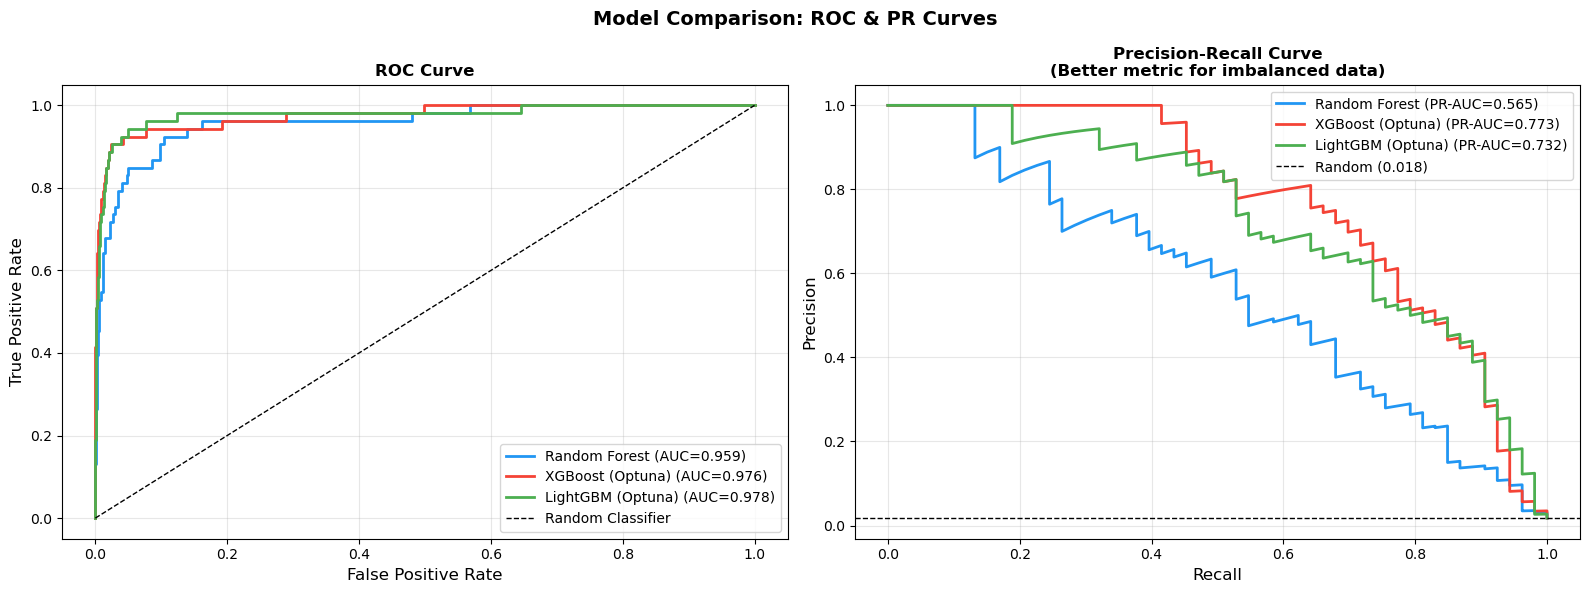

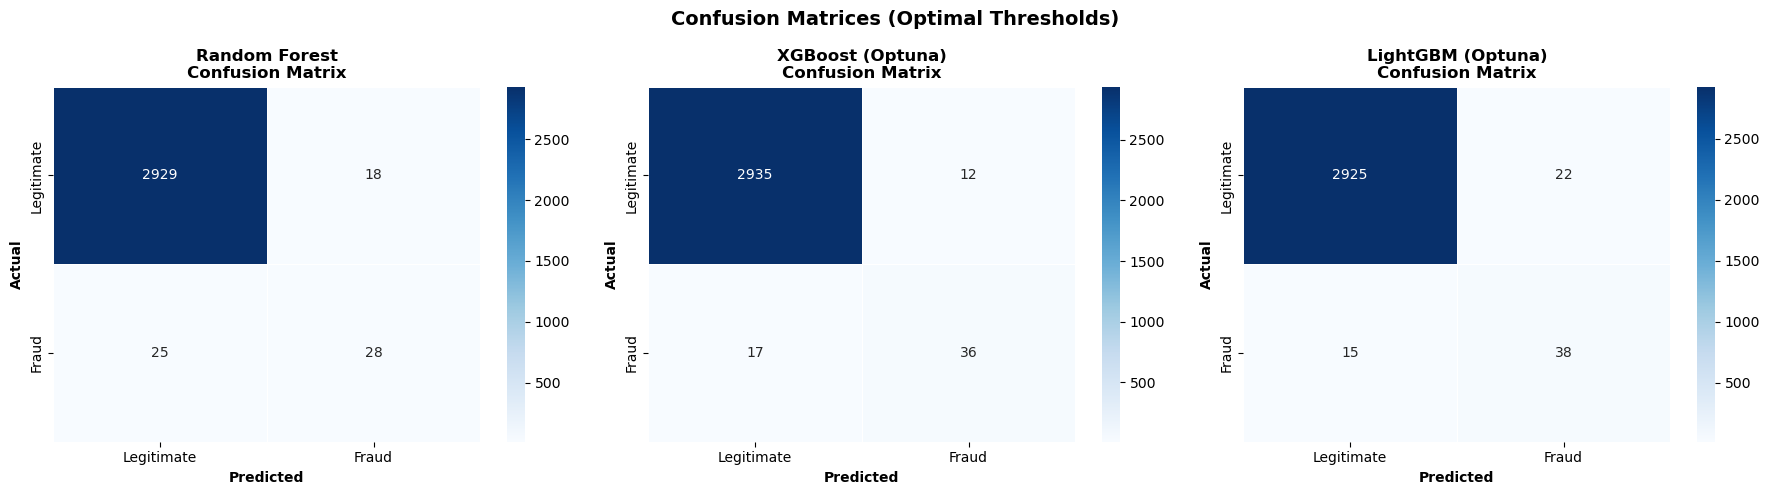


📊 MODEL COMPARISON SUMMARY


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Random Forest,0.985700,0.608700,0.528300,0.565700,0.958600,0.564600
XGBoost (Optuna),0.990300,0.750000,0.679200,0.712900,0.975800,0.772900
LightGBM (Optuna),0.987700,0.633300,0.717000,0.672600,0.978100,0.732000



🏆 Best Model by ROC-AUC: LightGBM (Optuna)


In [20]:
# Re-evaluate all models with optimal thresholds
best_t_rf,   _, _, _ = find_optimal_threshold(y_val, y_prob_rf,   'f1')
best_t_xgb,  _, _, _ = find_optimal_threshold(y_val, y_prob_xgb,  'f1')
best_t_lgbm, _, _, _ = find_optimal_threshold(y_val, y_prob_lgbm, 'f1')

y_pred_rf_opt   = (y_prob_rf   > best_t_rf).astype(int)
y_pred_xgb_opt  = (y_prob_xgb  > best_t_xgb).astype(int)
y_pred_lgbm_opt = (y_prob_lgbm > best_t_lgbm).astype(int)

all_results = []
prob_dict   = {}

for name, y_prob, y_pred_opt in [
    ("Random Forest",      y_prob_rf,   y_pred_rf_opt),
    ("XGBoost (Optuna)",   y_prob_xgb,  y_pred_xgb_opt),
    ("LightGBM (Optuna)",  y_prob_lgbm, y_pred_lgbm_opt),
]:
    res = evaluate_model(name, y_val, y_prob, y_pred_opt)
    all_results.append(res)
    prob_dict[name] = y_prob

# ROC & PR Curves
plot_roc_pr_curves(all_results, y_val, prob_dict)

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices (Optimal Thresholds)", fontsize=14, fontweight='bold')

for ax, res in zip(axes, all_results):
    plot_confusion_matrix(res['confusion_matrix'], res['model'], ax=ax)

plt.tight_layout()
plt.show()

# Summary Table
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['confusion_matrix']}
    for r in all_results
]).set_index('model').round(4)

print("\n" + "="*70)
print("📊 MODEL COMPARISON SUMMARY")
print("="*70)
display(metrics_df.style.highlight_max(axis=0, color='lightgreen')
                        .highlight_min(axis=0, color='blue'))

# Best model
best_model_name = metrics_df['roc_auc'].idxmax()
print(f"\n🏆 Best Model by ROC-AUC: {best_model_name}")

📊 Optuna Hyperparameter Importance - LightGBM


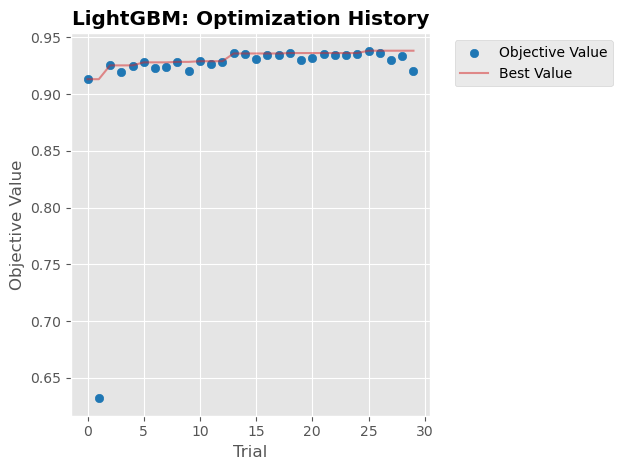

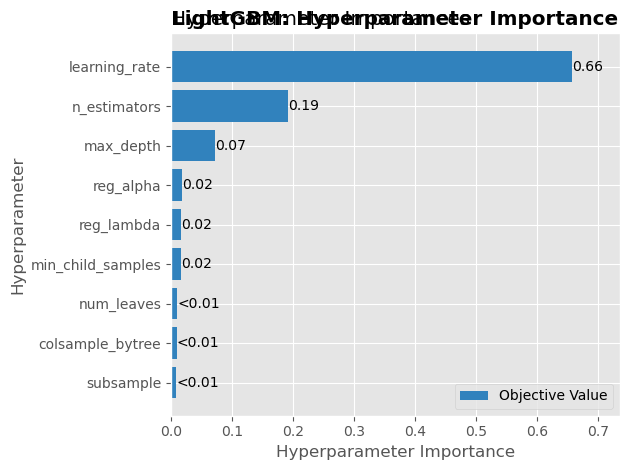

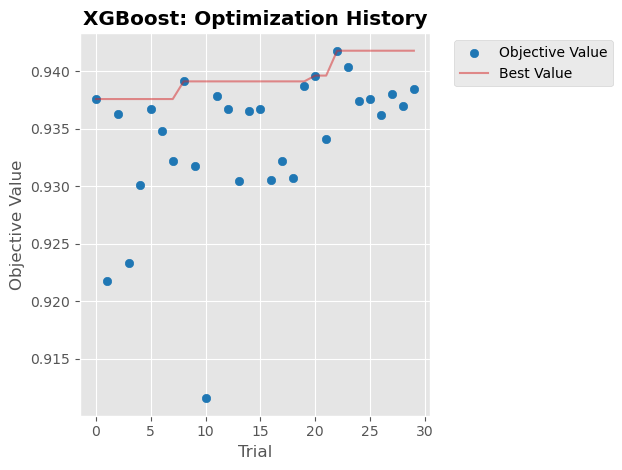

In [21]:
# Optuna study visualizations
print("📊 Optuna Hyperparameter Importance - LightGBM")

# Optimization history
fig = optuna.visualization.matplotlib.plot_optimization_history(lgbm_study)
plt.title("LightGBM: Optimization History", fontweight='bold')
plt.tight_layout()
plt.show()

# Parameter importance
try:
    fig = optuna.visualization.matplotlib.plot_param_importances(lgbm_study)
    plt.title("LightGBM: Hyperparameter Importance", fontweight='bold')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Param importance plot skipped: {e}")

# For XGBoost
fig = optuna.visualization.matplotlib.plot_optimization_history(xgb_study)
plt.title("XGBoost: Optimization History", fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Select best model for SHAP analysis
model_map = {
    "Random Forest"     : (rf_model,   y_prob_rf),
    "XGBoost (Optuna)"  : (xgb_model,  y_prob_xgb),
    "LightGBM (Optuna)" : (lgbm_model, y_prob_lgbm),
}

best_model_name = metrics_df['roc_auc'].idxmax()
best_model, best_y_prob = model_map[best_model_name]

print(f"🏆 Selected Best Model: {best_model_name}")
print(f"   ROC-AUC : {metrics_df.loc[best_model_name, 'roc_auc']:.4f}")
print(f"   F1 Score: {metrics_df.loc[best_model_name, 'f1']:.4f}")
print(f"   Recall  : {metrics_df.loc[best_model_name, 'recall']:.4f}")

🏆 Selected Best Model: LightGBM (Optuna)
   ROC-AUC : 0.9781
   F1 Score: 0.6726
   Recall  : 0.7170


🔍 Computing SHAP Values for Explainability...
   This may take 1-2 minutes...

✅ SHAP values computed for 500 samples
   Shape: (500, 22)


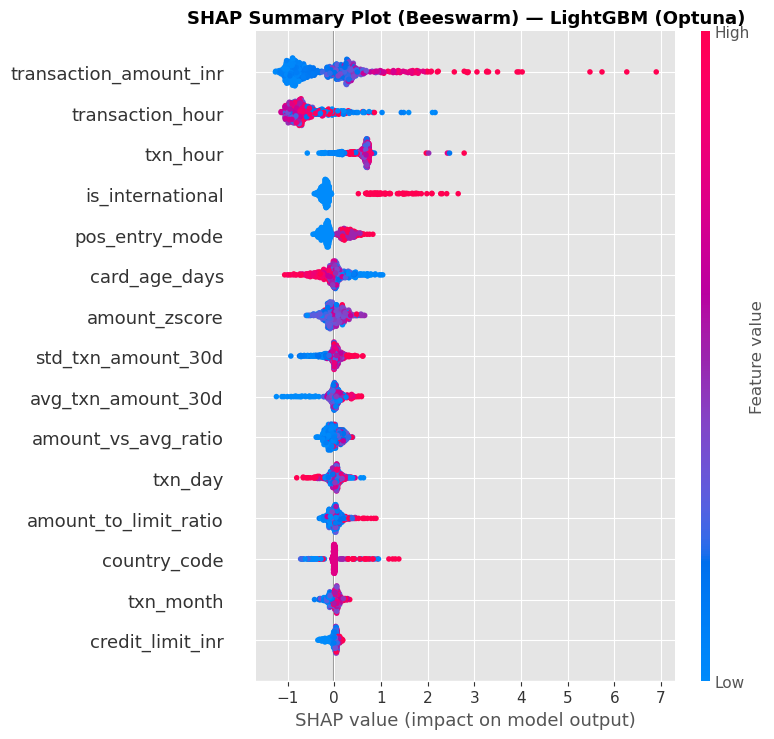

In [23]:
print("🔍 Computing SHAP Values for Explainability...")
print("   This may take 1-2 minutes...\n")

# Sample for speed (SHAP is expensive on large datasets)
sample_size = min(500, len(X_val_df))
X_shap_sample = X_val_df.sample(sample_size, random_state=42)

# TreeExplainer works for RF, XGB, LGBM
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, some models return list [class0, class1]
if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[1]  # SHAP values for class 1 (fraud)
else:
    shap_vals_fraud = shap_values

print(f"✅ SHAP values computed for {sample_size} samples")
print(f"   Shape: {shap_vals_fraud.shape}")

# --- PLOT 1: Beeswarm Summary Plot ---
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals_fraud,
    X_shap_sample,
    max_display=15,
    show=False
)
plt.title(f"SHAP Summary Plot (Beeswarm) — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

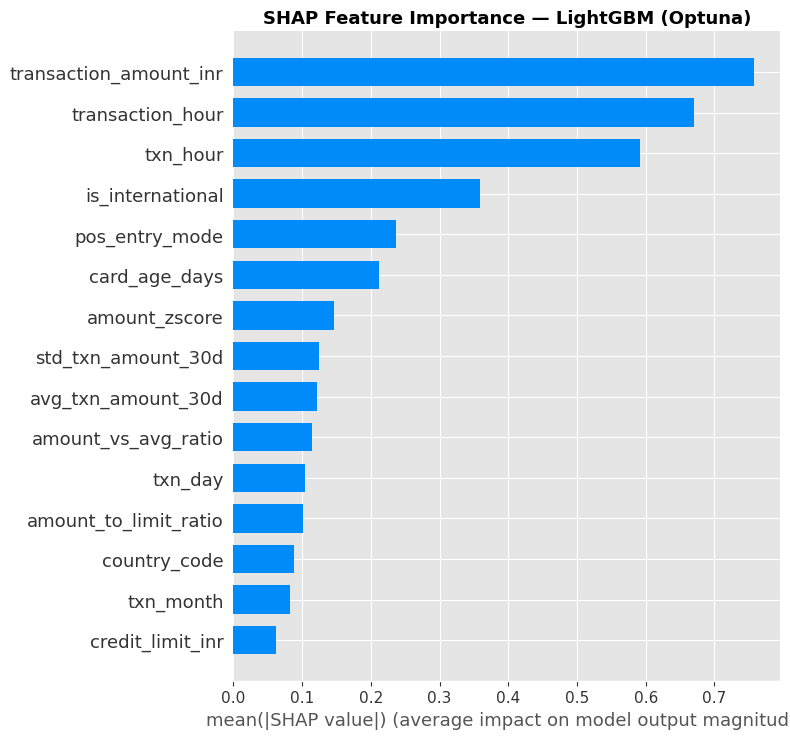


📊 Top Features by Mean |SHAP| Value:
               feature  mean_shap
transaction_amount_inr   0.757551
      transaction_hour   0.669848
              txn_hour   0.591461
      is_international   0.358159
        pos_entry_mode   0.236638
         card_age_days   0.211413
         amount_zscore   0.147030
    std_txn_amount_30d   0.123945
    avg_txn_amount_30d   0.122125
   amount_vs_avg_ratio   0.113617
               txn_day   0.103464
 amount_to_limit_ratio   0.101528
          country_code   0.088028
             txn_month   0.082122
      credit_limit_inr   0.061513


In [24]:
# --- PLOT 2: Global Feature Importance (Bar) ---
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals_fraud,
    X_shap_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title(f"SHAP Feature Importance — {best_model_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print top features ranked by mean |SHAP|
mean_shap = pd.DataFrame({
    'feature'    : X_shap_sample.columns,
    'mean_shap'  : np.abs(shap_vals_fraud).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("\n📊 Top Features by Mean |SHAP| Value:")
print(mean_shap.head(15).to_string(index=False))

In [26]:
# --- Explain Individual Suspicious Transactions ---
print("🔍 Individual Transaction SHAP Explanations\n")

# Step 1: Sample with positional index alignment
sample_size = min(500, len(X_val_df))

# Reset X_val_df index first to ensure 0-based
X_val_reset  = X_val_df.reset_index(drop=True)
y_val_reset  = y_val.reset_index(drop=True)

# Now sample safely — both share 0-based index
sample_idx      = np.random.RandomState(42).choice(len(X_val_reset), sample_size, replace=False)
X_shap_sample   = X_val_reset.iloc[sample_idx].reset_index(drop=True)
y_shap_sample   = y_val_reset.iloc[sample_idx].reset_index(drop=True)

# Step 2: Recompute SHAP values on the new clean sample
print(f"Computing SHAP values on {sample_size} samples...")
shap_values_sample = explainer.shap_values(X_shap_sample)

if isinstance(shap_values_sample, list):
    shap_vals_fraud = shap_values_sample[1]
else:
    shap_vals_fraud = shap_values_sample

print(f"✅ SHAP values ready. Shape: {shap_vals_fraud.shape}")

# Step 3: Get expected value
if isinstance(explainer.expected_value, (list, np.ndarray)):
    expected_val = float(explainer.expected_value[1])
else:
    expected_val = float(explainer.expected_value)

print(f"   Base (expected) value : {expected_val:.4f}")

# ── Find fraud cases using the aligned y_shap_sample ─────────────────────
fraud_positions = y_shap_sample[y_shap_sample == 1].index.tolist()
legit_positions = y_shap_sample[y_shap_sample == 0].index.tolist()

print(f"\n   Fraud cases in sample     : {len(fraud_positions)}")
print(f"   Legitimate cases in sample: {len(legit_positions)}")

# Choose positions to explain (prefer fraud cases)
if len(fraud_positions) >= 2:
    explain_positions = fraud_positions[:2]
elif len(fraud_positions) == 1:
    explain_positions = fraud_positions[:1]
else:
    print("⚠️  No fraud cases in sample — showing legitimate transactions instead.")
    explain_positions = legit_positions[:2]

# ── Explain each selected transaction ────────────────────────────────────
for pos in explain_positions:
    row_shap   = shap_vals_fraud[pos]
    sample_row = X_shap_sample.iloc[pos]
    true_label = y_shap_sample.iloc[pos]

    fraud_prob = best_model.predict_proba(
        X_shap_sample.iloc[[pos]]
    )[0, 1]

    print(f"\n{'─'*58}")
    print(f"  Sample Position : #{pos}")
    print(f"  True Label      : {'🚨 FRAUD' if true_label == 1 else '✅ Legitimate'}")
    print(f"  Fraud Probability: {fraud_prob:.4f}")
    print(f"{'─'*58}")

    feature_impact = pd.Series(row_shap, index=X_shap_sample.columns)

    top_pos = feature_impact.nlargest(5)
    top_neg = feature_impact.nsmallest(5)

    print("\n  🔴 Features INCREASING Fraud Risk:")
    for feat, val in top_pos.items():
        feat_val = sample_row[feat]
        print(f"     {feat:32s} = {feat_val:8.3f}  | SHAP: +{val:.4f}")

    print("\n  🟢 Features DECREASING Fraud Risk:")
    for feat, val in top_neg.items():
        feat_val = sample_row[feat]
        print(f"     {feat:32s} = {feat_val:8.3f}  | SHAP: {val:.4f}")

🔍 Individual Transaction SHAP Explanations

Computing SHAP values on 500 samples...
✅ SHAP values ready. Shape: (500, 22)
   Base (expected) value : -5.1457

   Fraud cases in sample     : 9
   Legitimate cases in sample: 491

──────────────────────────────────────────────────────────
  Sample Position : #51
  True Label      : 🚨 FRAUD
  Fraud Probability: 0.0020
──────────────────────────────────────────────────────────

  🔴 Features INCREASING Fraud Risk:
     txn_hour                         =   -0.807  | SHAP: +0.6795
     transaction_amount_inr           =   -0.107  | SHAP: +0.0971
     amount_to_limit_ratio            =    0.063  | SHAP: +0.0317
     std_txn_amount_30d               =    0.950  | SHAP: +0.0072
     country_code                     =    0.183  | SHAP: +0.0004

  🟢 Features DECREASING Fraud Risk:
     transaction_hour                 =   -0.799  | SHAP: -0.7345
     card_age_days                    =    0.948  | SHAP: -0.3626
     pos_entry_mode                   =


📊 SHAP Waterfall Plot


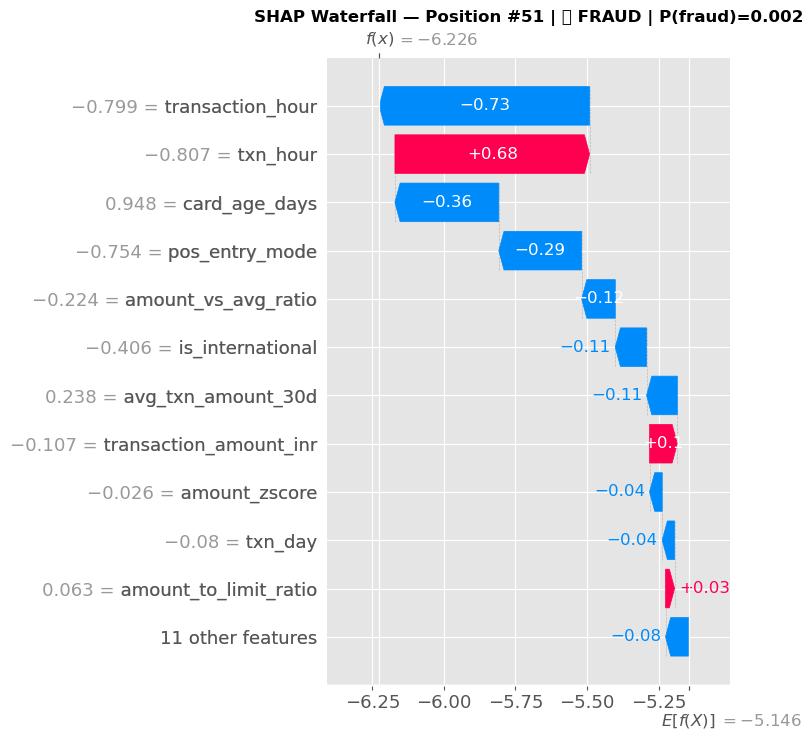

In [27]:
# ── Waterfall plot for first explained transaction ────────────────────────
print("\n📊 SHAP Waterfall Plot")

pos = explain_positions[0]

shap_explanation = shap.Explanation(
    values      = shap_vals_fraud[pos],
    base_values = expected_val,
    data        = X_shap_sample.iloc[pos].values,
    feature_names = X_shap_sample.columns.tolist()
)

plt.figure(figsize=(12, 7))
shap.plots.waterfall(shap_explanation, max_display=12, show=False)

true_label = y_shap_sample.iloc[pos]
fraud_prob = best_model.predict_proba(X_shap_sample.iloc[[pos]])[0, 1]

plt.title(
    f"SHAP Waterfall — Position #{pos} | "
    f"{'🚨 FRAUD' if true_label == 1 else '✅ Legit'} | "
    f"P(fraud)={fraud_prob:.3f}",
    fontweight='bold',
    fontsize=12
)
plt.tight_layout()
plt.show()

📊 SHAP Force Plot


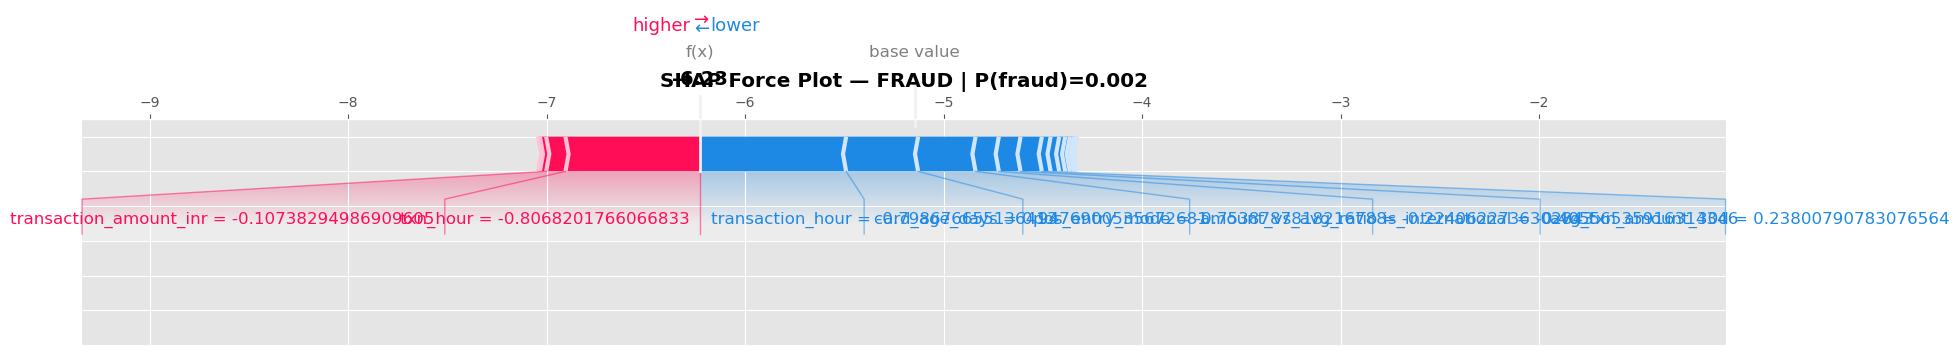

In [28]:
# ── Force plot for first explained transaction ────────────────────────────
print("📊 SHAP Force Plot")

pos = explain_positions[0]

shap.initjs()

force_plot = shap.force_plot(
    base_value    = expected_val,
    shap_values   = shap_vals_fraud[pos],
    features      = X_shap_sample.iloc[pos],
    feature_names = X_shap_sample.columns.tolist(),
    matplotlib    = True,
    show          = False,
    figsize       = (20, 4)
)

true_label = y_shap_sample.iloc[pos]
plt.title(
    f"SHAP Force Plot — {'FRAUD' if true_label==1 else 'Legitimate'} | "
    f"P(fraud)={best_model.predict_proba(X_shap_sample.iloc[[pos]])[0,1]:.3f}",
    fontweight='bold'
)
plt.tight_layout()
plt.show()

📊 Top Features by Mean |SHAP|:
               feature  mean_shap
transaction_amount_inr   0.757551
      transaction_hour   0.669848
              txn_hour   0.591461
      is_international   0.358159
        pos_entry_mode   0.236638
         card_age_days   0.211413
         amount_zscore   0.147030
    std_txn_amount_30d   0.123945
    avg_txn_amount_30d   0.122125
   amount_vs_avg_ratio   0.113617


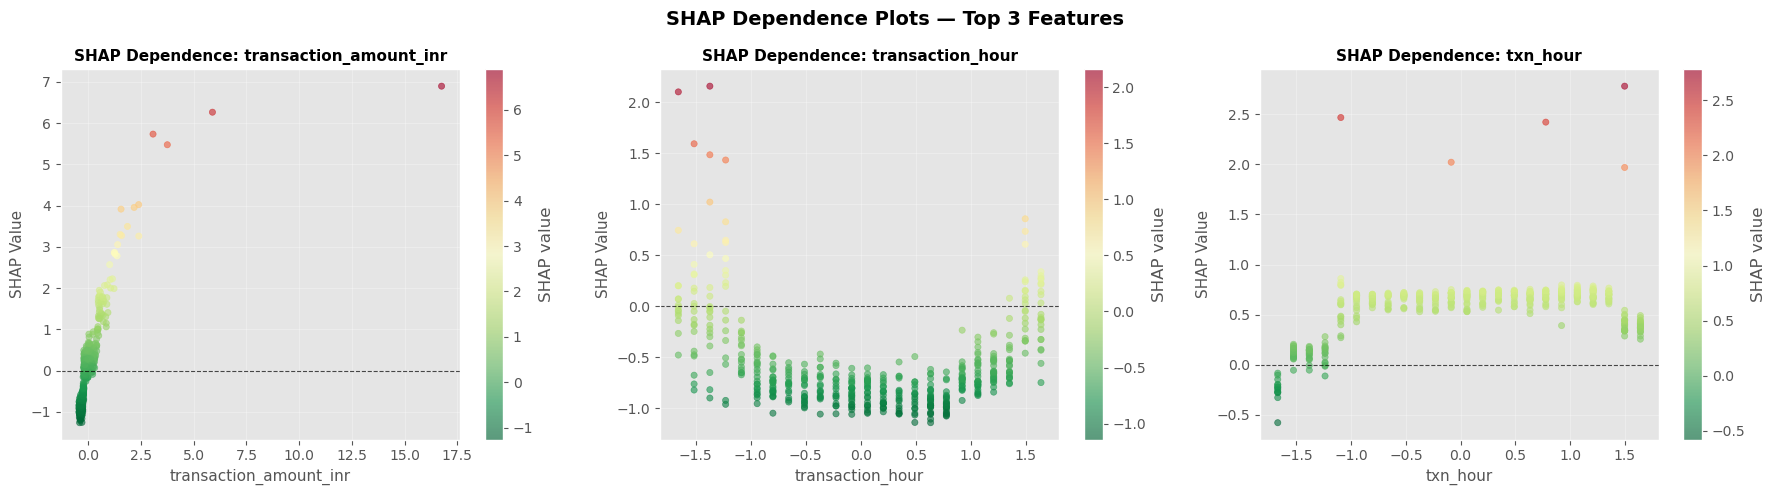

In [29]:
# ── SHAP Dependence Plots for top 3 features ─────────────────────────────
# Uses the newly computed shap_vals_fraud and X_shap_sample

mean_shap_fixed = pd.DataFrame({
    'feature'   : X_shap_sample.columns,
    'mean_shap' : np.abs(shap_vals_fraud).mean(axis=0)
}).sort_values('mean_shap', ascending=False).reset_index(drop=True)

print("📊 Top Features by Mean |SHAP|:")
print(mean_shap_fixed.head(10).to_string(index=False))

top_3_features = mean_shap_fixed['feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SHAP Dependence Plots — Top 3 Features", fontsize=14, fontweight='bold')

for ax, feat in zip(axes, top_3_features):
    feat_idx = list(X_shap_sample.columns).index(feat)
    sc = ax.scatter(
        X_shap_sample[feat],
        shap_vals_fraud[:, feat_idx],
        c=shap_vals_fraud[:, feat_idx],
        cmap='RdYlGn_r',
        alpha=0.6,
        s=20
    )
    plt.colorbar(sc, ax=ax, label='SHAP value')
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('SHAP Value', fontsize=11)
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=11, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
print("📁 Preparing Final Test Predictions...")

# --- Encode test data ---
for col in cat_cols:
    le = encoders[col]
    known_classes = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(
        lambda x: x if x in known_classes else le.classes_[0]
    )
    test_df[col] = le.transform(test_df[col])

# --- Drop leakage columns ---
test_df_clean = test_df.drop(columns=leak_cols, errors='ignore')

# --- Align columns with training ---
train_cols = X_train_df.columns.tolist()

for col in train_cols:
    if col not in test_df_clean.columns:
        test_df_clean[col] = 0

test_df_clean = test_df_clean[train_cols]

# --- Scale ---
test_scaled = scaler.transform(test_df_clean)
test_scaled_df = pd.DataFrame(test_scaled, columns=train_cols)

# --- Predict ---
y_test_prob = best_model.predict_proba(test_scaled_df)[:, 1]
y_test_pred = (y_test_prob > best_t_lgbm).astype(int)

# --- Submission ---
submission = pd.DataFrame({
    'predicted_fraud_probability' : y_test_prob,
    'predicted_fraud_label'       : y_test_pred
})

print(f"✅ Test predictions generated!")
print(f"   Total test samples  : {len(submission):,}")
print(f"   Predicted fraud     : {y_test_pred.sum():,} ({y_test_pred.mean()*100:.2f}%)")
print(f"\nSample predictions:")
display(submission.head(10))

submission.to_csv("fraud_predictions.csv", index=False)
print("\n✅ Saved to fraud_predictions.csv")

📁 Preparing Final Test Predictions...
✅ Test predictions generated!
   Total test samples  : 5,000
   Predicted fraud     : 95 (1.90%)

Sample predictions:


,predicted_fraud_probability,predicted_fraud_label
0,0.002353,0
1,0.008170,0
2,0.001066,0
3,0.010641,0
4,0.016050,0
5,0.001840,0
6,0.002588,0
7,0.002198,0
8,0.001504,0
9,0.002255,0



✅ Saved to fraud_predictions.csv
